# **Matrices de rotación simples en un espacio tridimensional**

**Docente:** PhD Jorge Rudas

**Diseño de prototipos - 2025 I**

**INFOTEP**

In [127]:
import numpy as np
from sympy import*
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
init_printing()

# **Función dibujar un vector punto en un espacio tridimencional**

In [128]:
def dibujar_punto(punto, label, x_lim = [0, 1], y_lim=[0, 1], z_lim=[0, 1]):
  """
  Dibuja un punto en un espacio tridimensional.

  Parametros:
    punto: Un vector NumPy de tres elementos representando las coordenadas (x, y, z) del punto.
    label: Una cadena de texto para etiquetar el punto en el gráfico.
    x_lim: Una lista de dos elementos que define los límites del eje x.
    y_lim: Una lista de dos elementos que define los límites del eje y.
    z_lim: Una lista de dos elementos que define los límites del eje z.
  """

  fig = plt.figure()
  ax = fig.add_subplot(111, projection='3d')

  ax.scatter(punto[0], punto[1], punto[2], color='b', label=label)

  ax.set_xlabel('X')
  ax.set_ylabel('Y')
  ax.set_zlabel('Z')
  ax.set_title('Espacio 3D')

  ax.quiver(0, 0, 0, punto[0], punto[1], punto[2], color='b')

  ax.set_xlim(x_lim)
  ax.set_ylim(y_lim)
  ax.set_zlim(z_lim)
  ax.legend()
  plt.show()



In [129]:
## Angulo simbolico
theta = symbols("theta",  real=True)

### **Rotación en el eje x**


In [130]:
## Matrix de rotación simbolica sobre le eje X
R_x = Matrix([[1, 0, 0], [0, cos(theta), -sin(theta)], [0, sin(theta), cos(theta)]])
R_x

⎡1    0        0   ⎤
⎢                  ⎥
⎢0  cos(θ)  -sin(θ)⎥
⎢                  ⎥
⎣0  sin(θ)  cos(θ) ⎦

### **Definición de un punto de prueba en el espacio tridimencional**

In [131]:
P0 = np.array([1, 1, 0])
print(P0)

[1 1 0]


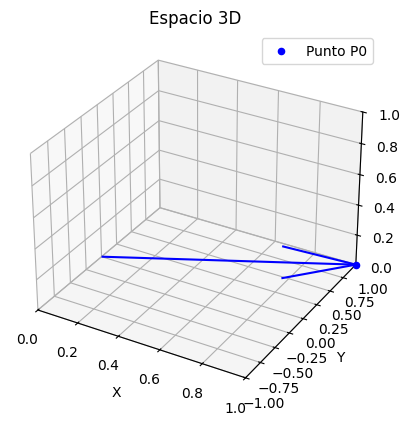

In [132]:
dibujar_punto(P0, "Punto P0", y_lim=[-1,1])

### **Aplicación de la matrix de rotación**



In [133]:
theta_val = np.pi #180 grados en radianes
R_p0 = np.array(R_x.subs({theta: theta_val})).astype(np.float64) #Se convierte theta simbolico a un valor concreto

P0_rotado = np.dot(R_p0, P0) #Producto punto entre la matrix de rotación y el vector de posición del punto
print(P0_rotado)

[ 1.0000000e+00 -1.0000000e+00  1.2246468e-16]


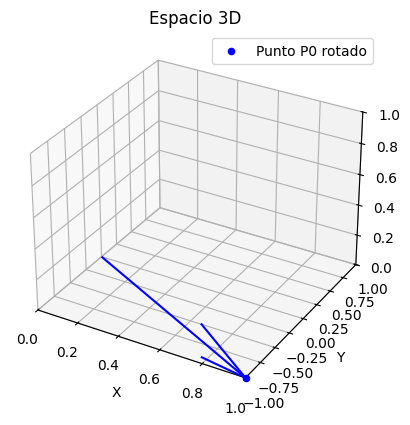

In [134]:
dibujar_punto(P0_rotado, "Punto P0 rotado", y_lim=[-1, 1])

### **Aplicación de la matrix de rotación**

In [135]:
theta_val = np.pi/4 # 45 grados en radianes
R_p0 = np.array(R_x.subs({theta: theta_val})).astype(np.float64) #Se convierte theta simbolico a un valor concreto

P0_rotado = np.dot(R_p0, P0) #Producto punto entre la matrix de rotación y el vector de posición del punto
print(P0_rotado)

[1.         0.70710678 0.70710678]


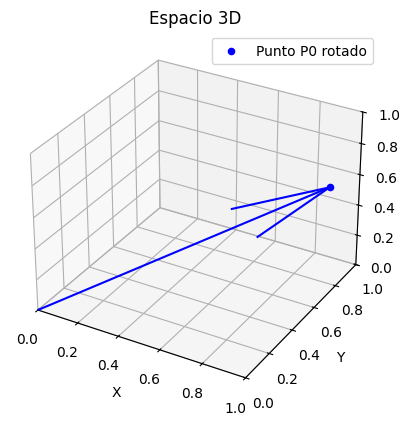

In [136]:
dibujar_punto(P0_rotado, "Punto P0 rotado", y_lim=[0, 1])

### **Rotación en el eje y**



In [137]:
R_y = Matrix([[cos(theta), 0, sin(theta)], [0, 1, 0], [-sin(theta), 0, cos(theta)]])
R_y

⎡cos(θ)   0  sin(θ)⎤
⎢                  ⎥
⎢   0     1    0   ⎥
⎢                  ⎥
⎣-sin(θ)  0  cos(θ)⎦

### **Rotación en el eje z**

In [138]:
R_z = Matrix([[cos(theta), -sin(theta), 0], [sin(theta), cos(theta), 0], [0, 0, 1]])
R_z

⎡cos(θ)  -sin(θ)  0⎤
⎢                  ⎥
⎢sin(θ)  cos(θ)   0⎥
⎢                  ⎥
⎣  0        0     1⎦

### **Ilustración angulos de rotación**

In [139]:
from IPython.display import Image


Image(url='https://www.researchgate.net/publication/348803228/figure/fig7/AS:984434408955905@1611718861641/a-Pitch-yaw-and-roll-angles-of-an-aircraft-with-body-orientation-O-u-v-original.ppm')


### **Multiples rotaciones**

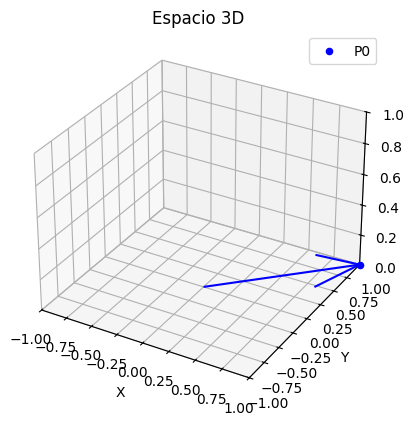

In [140]:
dibujar_punto(P0, "P0",x_lim=[-1, 1], y_lim=[-1, 1])

In [141]:
theta_val = np.pi # 180 grados en radianes
R_x_p0 = np.array(R_x.subs({theta: theta_val})).astype(np.float64) #Se convierte theta simbolico a un valor concreto Rx
R_y_p0 = np.array(R_y.subs({theta: theta_val})).astype(np.float64) #Se convierte theta simbolico a un valor concreto Ry
R_z_p0 = np.array(R_z.subs({theta: theta_val})).astype(np.float64) #Se convierte theta simbolico a un valor concreto Rz

P0_rotado_x = np.dot(R_x_p0, P0) #Producto punto entre la matrix de rotación y el vector de posición del punto
P0_rotado_y = np.dot(R_y_p0, P0_rotado_x) #Producto punto entre la matrix de rotación y el vector de posición del punto
P0_rotado_z = np.dot(R_z_p0, P0_rotado_y) #Producto punto entre la matrix de rotación y el vector de posición del punto

print(P0)
print(P0_rotado_x)
print(P0_rotado_y)
print(P0_rotado_z)

[1 1 0]
[ 1.0000000e+00 -1.0000000e+00  1.2246468e-16]
[-1.0000000e+00 -1.0000000e+00 -2.4492936e-16]
[ 1.0000000e+00  1.0000000e+00 -2.4492936e-16]


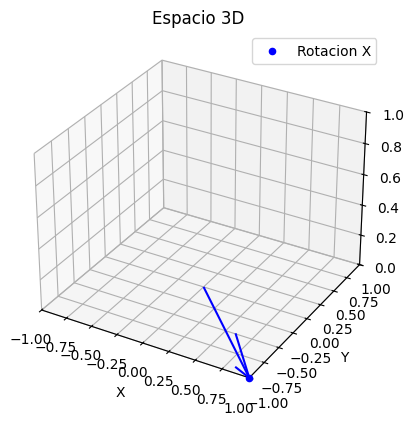

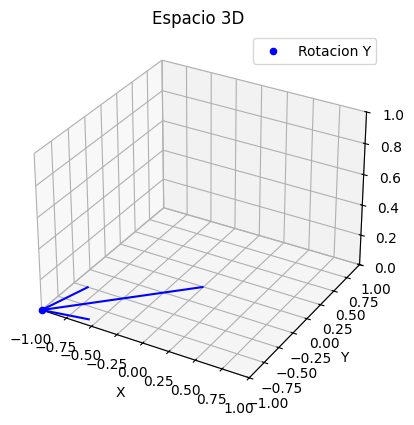

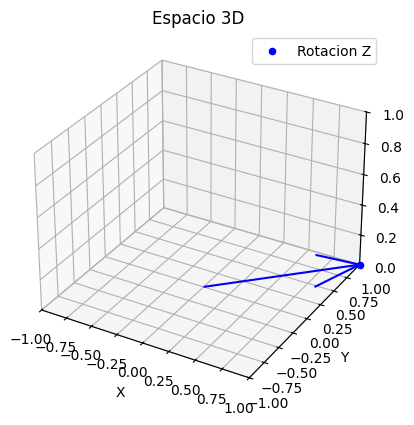

In [142]:
dibujar_punto(P0_rotado_x, label = 'Rotacion X', x_lim=[-1, 1], y_lim=[-1, 1])
dibujar_punto(P0_rotado_y, label = 'Rotacion Y', x_lim=[-1, 1], y_lim=[-1, 1])
dibujar_punto(P0_rotado_z, label = 'Rotacion Z', x_lim=[-1, 1], y_lim=[-1, 1])

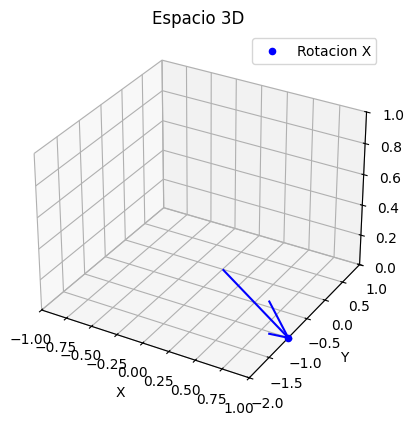

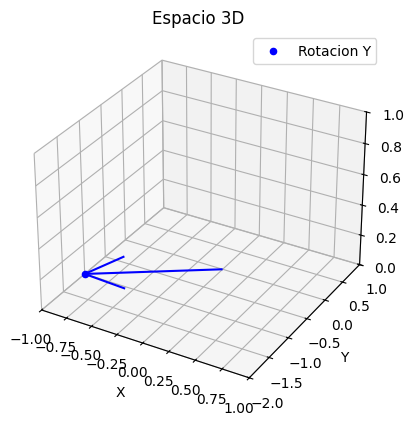

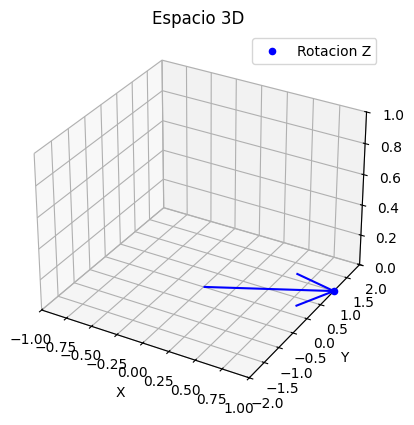

In [143]:
dibujar_punto(P0_rotado_x, label = 'Rotacion X', x_lim=[-1, 1], y_lim=[-2, 1])
dibujar_punto(P0_rotado_y, label = 'Rotacion Y', x_lim=[-1, 1], y_lim=[-2, 1])
dibujar_punto(P0_rotado_z, label = 'Rotacion Z', x_lim=[-1, 1], y_lim=[-2, 2])

Punto original: [1 1 0]
Vector de traslación: [ 2 -1  3]
Punto trasladado: [3 0 3]


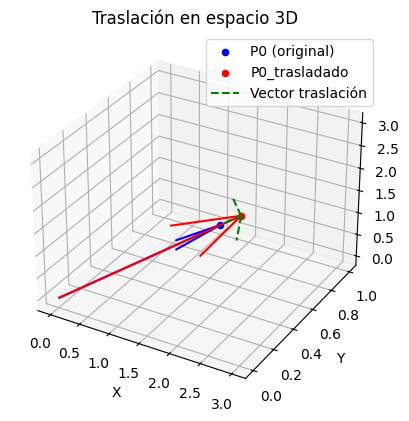

In [144]:
def trasladar_punto(punto, traslacion):
  """
  Realiza una traslación de un punto en el espacio tridimensional.

  Parámetros:
    punto: Un vector NumPy de tres elementos representando las coordenadas (x, y, z) del punto.
    traslacion: Un vector NumPy de tres elementos representando el vector de traslación (dx, dy, dz).

  Retorna:
    Un vector NumPy con las nuevas coordenadas del punto trasladado.
  """
  return punto + traslacion

# Ejemplo de uso de la función de traslación
if __name__ == "__main__":
    # Punto original
    P0 = np.array([1, 1, 0])
    print("Punto original:", P0)

    # Vector de traslación
    T = np.array([2, -1, 3])
    print("Vector de traslación:", T)

    # Aplicar traslación
    P0_trasladado = trasladar_punto(P0, T)
    print("Punto trasladado:", P0_trasladado)

    # Visualizar ambos puntos
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Punto original
    ax.scatter(P0[0], P0[1], P0[2], color='b', label='P0 (original)')
    ax.quiver(0, 0, 0, P0[0], P0[1], P0[2], color='b')

    # Punto trasladado
    ax.scatter(P0_trasladado[0], P0_trasladado[1], P0_trasladado[2], color='r', label='P0_trasladado')
    ax.quiver(0, 0, 0, P0_trasladado[0], P0_trasladado[1], P0_trasladado[2], color='r')

    # Vector de traslación
    ax.quiver(P0[0], P0[1], P0[2], T[0], T[1], T[2], color='g', linestyle='--', label='Vector traslación')

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('Traslación en espacio 3D')
    ax.legend()
    plt.show()

# **Actividad**

1.   Evalue el efecto del orden de las rotaciones y saque sus propias conclusiones
2.   Agregue una función que re utilice la implementación compartida para hacer traslaciones